# MoLA Training Tutorial

Train a model on the simple and small fraction-subtraction dataset.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Step 1: Download the Fraction-Subtraction Dataset

In [4]:
import pyreadr
import requests
import tempfile

# Helper function to retrieve data from Github
def download_R_file_to_pandas(file_name):

    # Path to datasets in Github CDM repo
    path = "https://raw.githubusercontent.com/cran/CDM/master/data/"
    response = requests.get(path + file_name + ".rda")
    response.raise_for_status()

    # Write .RDA file to temp and load using pyreadr
    with tempfile.NamedTemporaryFile(suffix=".rda", delete=True) as f:
        f.write(response.content)
        f.flush()

        result = pyreadr.read_r(f.name)

    # Fetch pandas dataframe
    df = result[file_name]
    return df

### Step 1a: Download Item-Response Data Matrix
`X`: binary user-item matrix, where a "1" signifies a correct response and a "0" signifies an incorrect response.

In [5]:
# Download the data
X_df = download_R_file_to_pandas("fraction.subtraction.data")

# Convert to NumPy array
X = X_df.to_numpy()  

# Print shape and header
print("Item response data shape:", X_df.shape)
X_df.head()

Item response data shape: (536, 20)


,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Item9,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,0,0,0,1,0,0,1,1,0,1,1,1,0,1,1,1,0,1,1,1
1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,1,1,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0,0,0
3,1,1,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,1,0,1
4,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0


### Step 1b: Download the Q-matrix

`Q_matrix`: binary item-skill matrix, where a "1" signifies that the item requires the skill, and "0" signifies the opposite.

In [6]:
Q_df = download_R_file_to_pandas("fraction.subtraction.qmatrix")

# Convert to NumPy array
Q_matrix = Q_df.to_numpy()

# Print shape and header
print("Item response data shape:", Q_df.shape)
Q_df.head()

Item response data shape: (20, 8)


,alpha1,alpha2,alpha3,alpha4,alpha5,alpha6,alpha7,alpha8
rownames,,,,,,,,
Item1,0,0,0,1,0,1,1,0
Item2,0,0,0,1,0,0,1,0
Item3,0,0,0,1,0,0,1,0
Item4,0,1,1,0,1,0,1,0
Item5,0,1,0,1,0,0,1,1


## Step 2: Configure and Train the Model

## Stress Test Experiment
Fit a model with way too many components.

In [ ]:
from src.mola import MoLA

# Configure model parameters (current sklearn-style API)
model_params = {
    'Q': Q_matrix,
    'n_components': 5,
    'mu_prior': (2, 2),
    'theta_prior': (2, 2),
    'pi_prior': 1,
    'tol': 1e-5,
    'max_iter': 50,
    'pseudo_likelihood': False,
    'init': 'k-means',
}

# Instantiate the model
mola = MoLA(**model_params)

# Fit the model to the data
mola.fit(X)


## Step 3: Visualize Training Results

Negative Log-Likelihood: 0.004493157761701844


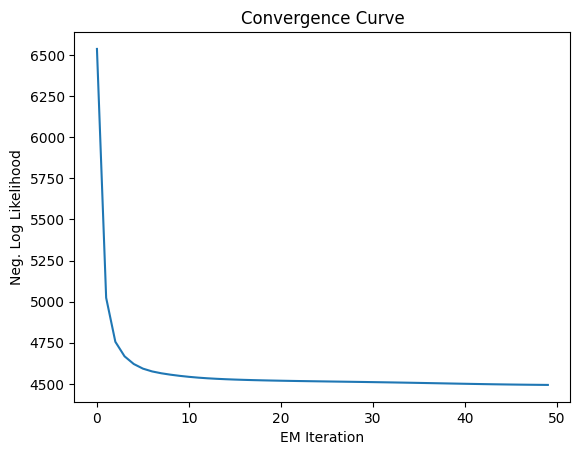

In [8]:
print("Negative Log-Likelihood:", mola.nll_trace[-1] * (1e-6))

plt.plot(mola.nll_trace)
plt.title('Convergence Curve')
plt.ylabel('Neg. Log Likelihood')
plt.xlabel('EM Iteration')
plt.show()

### Step 3b: Visualize Proficiency Components

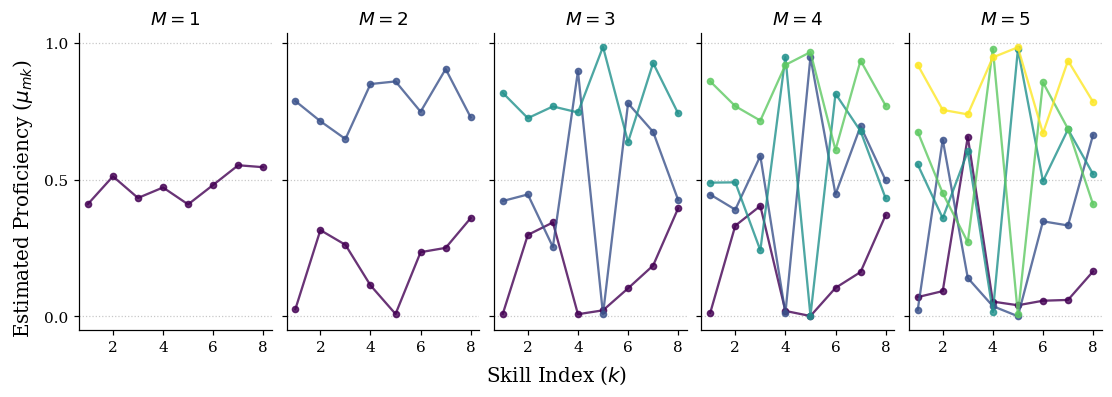

In [ ]:
# Set plotting context for Academic Paper (plain matplotlib -- seaborn is
# not a declared project dependency; see requirements.txt)
plt.rcParams['font.family'] = 'serif' # Matches LaTeX default
plt.rcParams['axes.unicode_minus'] = False

component_list = [1, 2, 3, 4, 5]
n = len(component_list)

colors = plt.cm.viridis(np.linspace(0, 1, max(component_list)))

fig, axes = plt.subplots(1, n, figsize=(10, 3.5), sharey=True, constrained_layout=True)

for i, (ax, n_comp) in enumerate(zip(axes, component_list)):
    # Standardize model setup (k-means initialization: Section~\ref{sec:parameter-recovery-stability}
    # shows this is far more reproducible than random initialization, confirmed again for this
    # dataset in the stability check below)
    model_params = {
        'Q': Q_matrix,
        'n_components': n_comp,
        'mu_prior': (2, 2),
        'theta_prior': (2, 2),
        'pi_prior': 1,
        'tol': 1e-5,
        'max_iter': 100,
        'init': 'k-means',
        'random_state': 42,
    }

    model_qual = MoLA(**model_params)
    model_qual.fit(X)

    # Sort components by mean proficiency to keep colors consistent across plots
    # This makes M=2 and M=3 look like evolutions of each other
    sorted_idx = np.argsort(model_qual.mu.mean(axis=1))

    for rank, k in enumerate(sorted_idx):
        ax.plot(range(1, model_qual.mu.shape[1] + 1), model_qual.mu[k, :],
                color=colors[rank],
                marker='o', markersize=4,
                linewidth=1.5, alpha=0.8)

    ax.set_title(f'$M={n_comp}$', fontsize=12, fontweight='bold')
    ax.set_xticks([2, 4, 6, 8]) # Show only key indices to prevent crowding
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Global labels
fig.supxlabel("Skill Index ($k$)", fontsize=13)
fig.supylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=13)

# Save in vector formats for high-quality printing
plt.savefig("./figures/mola_profiles_comparison.pdf", bbox_inches="tight")
plt.show()


In [10]:
labels = [
    "Convert a whole number to a fraction",
    "Separate a whole number from a fraction",
    "Simplify before subtracting",
    "Find a common denominator",
    "Borrow from the whole number part",
    "Column borrow to subtract the second numerator from the first",
    "Subtract numerators",
    "Reduce answers to simplest form"
]

df = pd.DataFrame(model_qual.mu).T
df.index = labels
df

,0,1,2,3,4
Convert a whole number to a fraction,0.914588,0.530878,0.020838,0.068751,0.658566
Separate a whole number from a fraction,0.725726,0.326714,0.611228,0.078748,0.412692
Simplify before subtracting,0.734013,0.611749,0.139562,0.633093,0.267334
Find a common denominator,0.959259,0.015629,0.051273,0.068311,0.984267
Borrow from the whole number part,0.982357,0.967947,0.000198,0.039887,0.005893
Column borrow to subtract the second numerator from the first,0.682730,0.506337,0.354519,0.058701,0.861365
Subtract numerators,0.834552,0.452443,0.144610,0.021551,0.439699
Reduce answers to simplest form,0.797956,0.538842,0.684423,0.175413,0.425397


### Visualize Difficulty

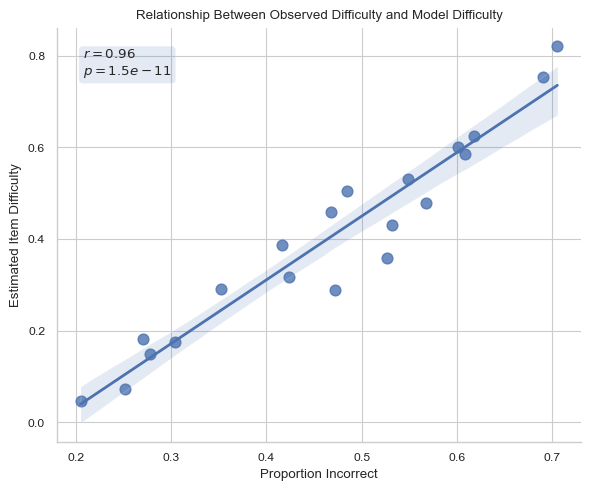

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

x = 1 - X_df.mean(axis=0)  # proportion incorrect
y = mola.get_item_difficulty()

r, p = pearsonr(x, y)

sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 5))

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"linewidth": 2},
    ax=ax,
)

ax.set_xlabel("Proportion Incorrect")
ax.set_ylabel("Estimated Item Difficulty")
ax.set_title("Relationship Between Observed Difficulty and Model Difficulty")

ax.text(
    0.05,
    0.95,
    f"$r={r:.2f}$\n$p={p:.2g}$",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15),
)

sns.despine()
plt.tight_layout()
plt.show()

## Compare Negatively Correlated Archetypes

In [ ]:
import pandas as pd
from itertools import combinations
from scipy.stats import pearsonr

# Select the MOST ANTI-CORRELATED pair among all C(5,2) archetype pairs --
# not the two closest to the median mean proficiency. The latter heuristic
# (this cell's old logic) picks an unrelated, weakly-correlated pair; the
# polarized-procedural-dichotomy story in the paper is specifically about
# the pair with the strongest negative correlation.
mu = model_qual.mu
pairs = list(combinations(range(mu.shape[0]), 2))
corrs = {(i, j): pearsonr(mu[i], mu[j])[0] for i, j in pairs}
i, j = min(corrs, key=corrs.get)
print(f"Most anti-correlated pair: components ({i}, {j}), r={corrs[(i, j)]:.3f}")
print(f"Mean proficiency: {mu[i].mean():.3f} / {mu[j].mean():.3f}")

r = pd.DataFrame(mu[[i, j], :]).T
print('corr:', r.corr().iloc[1, 0])

r.index = labels
r.columns = ['Archetype A', 'Archetype B']
r = r.round(3)
print('\n', r.to_latex())
print(r.mean())
r


Most anti-correlated pair: components (0, 3), r=-0.740
Mean proficiency: 0.526 / 0.542
corr: -0.7395704984998238

 \begin{tabular}{lrr}
\toprule
 & Archetype A & Archetype B \\
\midrule
Convert a whole number to a fraction & 0.556000 & 0.676000 \\
Separate a whole number from a fraction & 0.359000 & 0.450000 \\
Simplify before subtracting & 0.603000 & 0.272000 \\
Find a common denominator & 0.015000 & 0.980000 \\
Borrow from the whole number part & 0.977000 & 0.007000 \\
Column borrow to subtract the second numerator from the first & 0.494000 & 0.856000 \\
Subtract numerators & 0.684000 & 0.686000 \\
Reduce answers to simplest form & 0.520000 & 0.409000 \\
\bottomrule
\end{tabular}

Archetype A    0.526
Archetype B    0.542
dtype: float64


### Stability of the archetype pair across initializations
Re-fits M=5 ten times under random and ten times under k-means initialization, and reports the correlation of the most anti-correlated archetype pair each time. Feeds the stability sentences in the qualitative and simulation sections of the paper.


In [ ]:
# Stability of the archetype pair's correlation across repeated initializations,
# random vs. k-means, at M=5. Reused by the paper's qualitative-section and
# simulation-section stability sentences.
import numpy as np
from itertools import combinations
from scipy.stats import pearsonr

def most_anticorrelated_r(init, seed):
    m = MoLA(Q=Q_matrix, n_components=5, mu_prior=(2, 2), theta_prior=(2, 2), pi_prior=1,
             tol=1e-5, max_iter=100, pseudo_likelihood=False, init=init, random_state=seed)
    m.fit(X)
    mu = m.mu
    return min(pearsonr(mu[i], mu[j])[0] for i, j in combinations(range(5), 2))

SEEDS = range(10)
r_random = np.array([most_anticorrelated_r("random", s) for s in SEEDS])
r_kmeans = np.array([most_anticorrelated_r("k-means", s) for s in SEEDS])

print(f"Random init:  r = {r_random.mean():.3f} +/- {r_random.std(ddof=1):.3f}  (range {r_random.min():.3f} to {r_random.max():.3f})")
print(f"K-means init: r = {r_kmeans.mean():.3f} +/- {r_kmeans.std(ddof=1):.3f}  (range {r_kmeans.min():.3f} to {r_kmeans.max():.3f})")
print(f"K-means SD is {r_random.std(ddof=1) / r_kmeans.std(ddof=1):.0f}x smaller than random-init SD, across {len(SEEDS)} seeds each.")


Random init:  r = -0.750 +/- 0.072  (range -0.858 to -0.636)
K-means init: r = -0.740 +/- 0.000  (range -0.740 to -0.740)
K-means SD is 392x smaller than random-init SD, across 10 seeds each.


## Comparison Against DINA

In [13]:
from src.cdm.dina import DINA

dina = DINA()
dina.fit(X_df, Q_df)

-----------------------------------------------------------------------
DINA MODEL 
** 2026-06-10 23:53:28.566344 
---------------------------------------------------------------------------------
Iter.  1  :  23:53:28.5812 ,   loglike= -5129.088  / max. param. ch. :  0.195669  / relative deviance change :  1
Iter.  2  :  23:53:28.587318 ,   loglike= -4534.616  / max. param. ch. :  0.078765  / relative deviance change :  0.131096
Iter.  3  :  23:53:28.593695 ,   loglike= -4454.8  / max. param. ch. :  0.045692  / relative deviance change :  0.017917
Iter.  4  :  23:53:28.600041 ,   loglike= -4429.377  / max. param. ch. :  0.028132  / relative deviance change :  0.00574
Iter.  5  :  23:53:28.605843 ,   loglike= -4417.867  / max. param. ch. :  0.024407  / relative deviance change :  0.002605
Iter.  6  :  23:53:28.612341 ,   loglike= -4412.064  / max. param. ch. :  0.020998  / relative deviance change :  0.001315
Iter.  7  :  23:53:28.618424 ,   loglike= -4408.769  / max. param. ch. :  0.0

In [45]:
P_m_X = mola.get_posterior(X)
P_a_X = dina.pred_profile_probas(X_df)

# inputs
P_m_X = mola.get_posterior(X)          # (N, M)
P_a_X = dina.pred_profile_probas(X_df) # (N, A=256)

# joint alignment (key object)
C = P_a_X.T @ P_m_X   # (A, M)

# Convert to P(m | a)
C_norm = C / (C.sum(axis=1, keepdims=True) + 1e-12)

# marginals
P_a = P_a_X.mean(axis=0)
P_m = P_m_X.mean(axis=0)

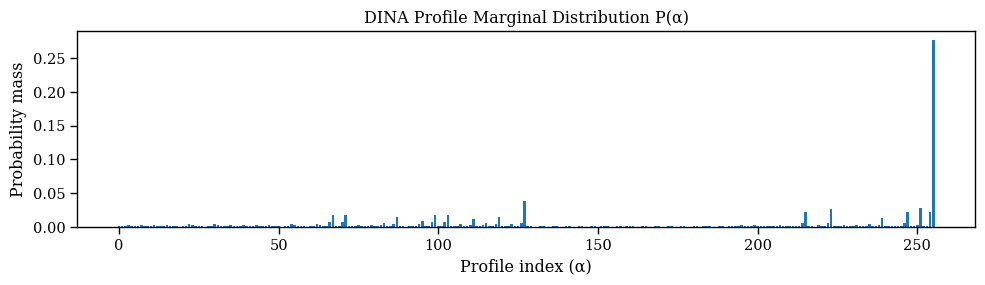

In [46]:
plt.figure(figsize=(10, 3))
plt.bar(np.arange(len(P_a)), P_a)
plt.title("DINA Profile Marginal Distribution P(α)")
plt.xlabel("Profile index (α)")
plt.ylabel("Probability mass")
plt.tight_layout()
plt.show()

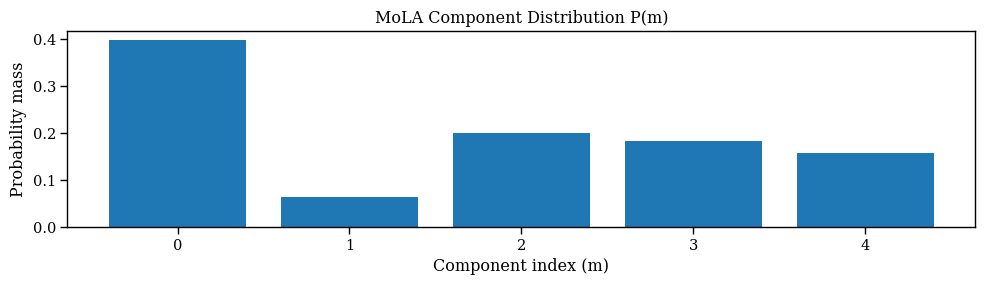

In [47]:
plt.figure(figsize=(10, 3))
plt.bar(np.arange(len(P_m)), P_m)
plt.title("MoLA Component Distribution P(m)")
plt.xlabel("Component index (m)")
plt.ylabel("Probability mass")
plt.tight_layout()
plt.show()

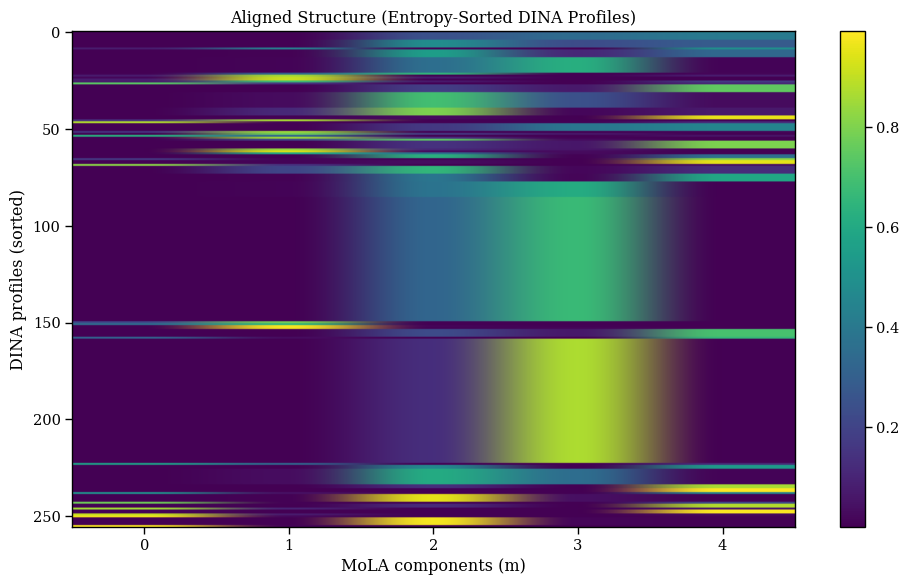

In [48]:
# sort DINA profiles by entropy (makes structure visible)
entropy = -(P_a_X * np.log(P_a_X + 1e-12)).sum(axis=0)
order = np.argsort(entropy)

C_sorted = C_norm[order, :]
plt.figure(figsize=(10, 6))
plt.imshow(C_sorted, aspect='auto', cmap='viridis')
plt.colorbar()

plt.xlabel("MoLA components (m)")
plt.ylabel("DINA profiles (sorted)")
plt.title("Aligned Structure (Entropy-Sorted DINA Profiles)")

plt.tight_layout()
plt.show()

## Tatsuoka's Rule Analysis

                       A1     A2     A3     A4     A5
Regrouping          0.874  0.609  0.211  0.062  0.359
Common Denominator  0.959  0.016  0.051  0.068  0.984
Execution           0.759  0.479  0.250  0.040  0.651
Simplification      0.766  0.575  0.412  0.404  0.346


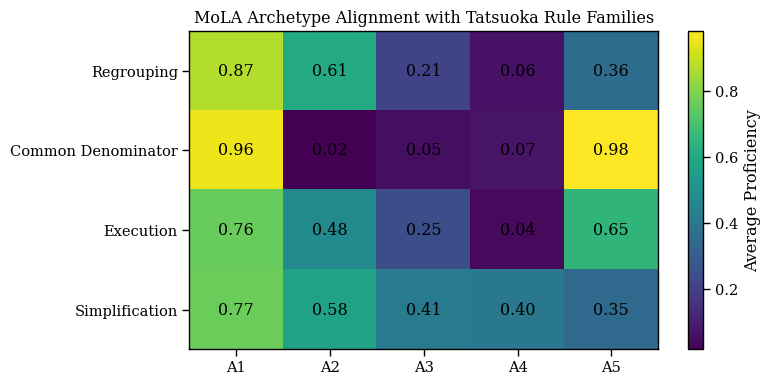

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Tatsuoka-style rule family mapping
# --------------------------------------------------

rule_families = {
    "Regrouping": [
        "Convert a whole number to a fraction",
        "Separate a whole number from a fraction",
        "Borrow from the whole number part",
    ],
    "Common Denominator": [
        "Find a common denominator",
    ],
    "Execution": [
        "Column borrow to subtract the second numerator from the first",
        "Subtract numerators",
    ],
    "Simplification": [
        "Simplify before subtracting",
        "Reduce answers to simplest form",
    ],
}

# --------------------------------------------------
# Aggregate archetypes by rule family
# --------------------------------------------------

rule_df = pd.DataFrame(
    {
        rule: df.loc[attrs].mean(axis=0)
        for rule, attrs in rule_families.items()
    }
).T

rule_df.columns = [f"A{i+1}" for i in rule_df.columns]

print(rule_df.round(3))

# --------------------------------------------------
# Heatmap
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(rule_df.values, aspect="auto")

ax.set_xticks(np.arange(len(rule_df.columns)))
ax.set_xticklabels(rule_df.columns)

ax.set_yticks(np.arange(len(rule_df.index)))
ax.set_yticklabels(rule_df.index)

for i in range(rule_df.shape[0]):
    for j in range(rule_df.shape[1]):
        ax.text(
            j,
            i,
            f"{rule_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

cbar = plt.colorbar(im)
cbar.set_label("Average Proficiency")

plt.title("MoLA Archetype Alignment with Tatsuoka Rule Families")
plt.tight_layout()
plt.savefig(
    "./figures/mola_tatsuoka_heatmap.pdf",
    bbox_inches="tight"
)
plt.show()

In [ ]:
# --------------------------------------------------
# LaTeX table 1:
# Rule-family summary
# --------------------------------------------------

latex_rule_table = rule_df.round(3).to_latex(
    caption=(
        "Average proficiency within Tatsuoka-style "
        "rule families for each MoLA archetype."
    ),
    label="tab:tatsuoka_rule_alignment",
    float_format="%.3f",
)

print("\n\nRULE FAMILY TABLE\n")
print(latex_rule_table)

# # --------------------------------------------------
# # Determine dominant rule family
# # --------------------------------------------------

# dominant_rule = rule_df.idxmax(axis=0)

# summary_df = pd.DataFrame({
#     "Dominant Rule Family": dominant_rule
# })

# summary_df.index.name = "Archetype"

# # --------------------------------------------------
# # Optional: overall archetype proficiency
# # --------------------------------------------------

# mean_prof = df.mean(axis=0)

# summary_df["Mean Proficiency"] = mean_prof.values

# summary_df = summary_df[
#     ["Mean Proficiency", "Dominant Rule Family"]
# ]

# # --------------------------------------------------
# # LaTeX table 2:
# # Archetype interpretation summary
# # --------------------------------------------------

# latex_summary_table = summary_df.round(3).to_latex(
#     caption=(
#         "Dominant Tatsuoka-style rule family for "
#         "each MoLA archetype."
#     ),
#     label="tab:archetype_rule_summary",
#     float_format="%.3f",
# )

# print("\n\nARCHETYPE SUMMARY TABLE\n")
# print(latex_summary_table)

NameError: name 'rule_df' is not defined